In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')
print("All libraries loaded successfully!")

All libraries loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
import urllib.request
import zipfile

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
urllib.request.urlretrieve(url, "spam.zip")
with zipfile.ZipFile("spam.zip", "r") as z:
    z.extractall(".")
df = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["label", "message"])

print("Dataset shape:", df.shape)
print("\nLabel counts:")
print(df["label"].value_counts())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (5572, 2)

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


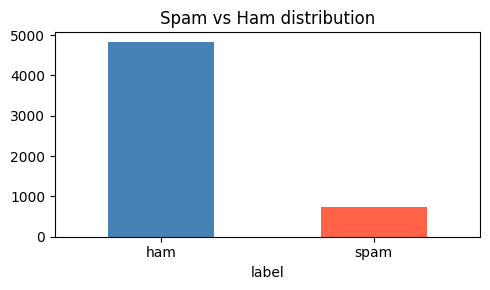

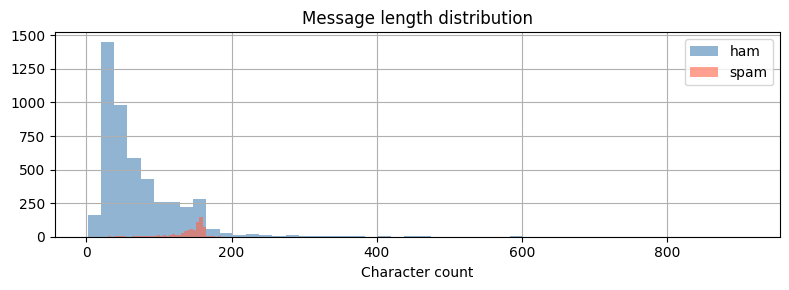

Average length — Ham: 71
Average length — Spam: 139


In [3]:
plt.figure(figsize=(5,3))
df["label"].value_counts().plot(kind="bar", color=["steelblue","tomato"])
plt.title("Spam vs Ham distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
df["length"] = df["message"].apply(len)

plt.figure(figsize=(8,3))
for label, color in [("ham","steelblue"), ("spam","tomato")]:
    df[df["label"]==label]["length"].hist(bins=50, alpha=0.6, color=color, label=label)
plt.legend()
plt.title("Message length distribution")
plt.xlabel("Character count")
plt.tight_layout()
plt.show()

print("Average length — Ham:", round(df[df.label=="ham"]["length"].mean()))
print("Average length — Spam:", round(df[df.label=="spam"]["length"].mean()))

In [4]:
stop_words = set(stopwords.words("english"))
ps = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [ps.stem(w) for w in tokens
              if w not in stop_words]
    return " ".join(tokens)

df["clean"] = df["message"].apply(preprocess)
print("Original: ", df["message"][0])
print("Cleaned:  ", df["clean"][0])
print()
print("Original: ", df["message"][4])
print("Cleaned:  ", df["clean"][4])

Original:  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned:   go jurong point crazi avail bugi n great world la e buffet cine got amor wat

Original:  Nah I don't think he goes to usf, he lives around here though
Cleaned:   nah dont think goe usf live around though


In [5]:

X = df["clean"]
y = (df["label"] == "spam").astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf  = tfidf.transform(X_test)
nb = MultinomialNB()
nb.fit(X_train_tf, y_train)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tf, y_train)
print("Models trained successfully!")
print(f"Training samples: {X_train_tf.shape[0]}, Test samples: {X_test_tf.shape[0]}")

Models trained successfully!
Training samples: 4457, Test samples: 1115



  Naive Bayes
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115


  Logistic Regression
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



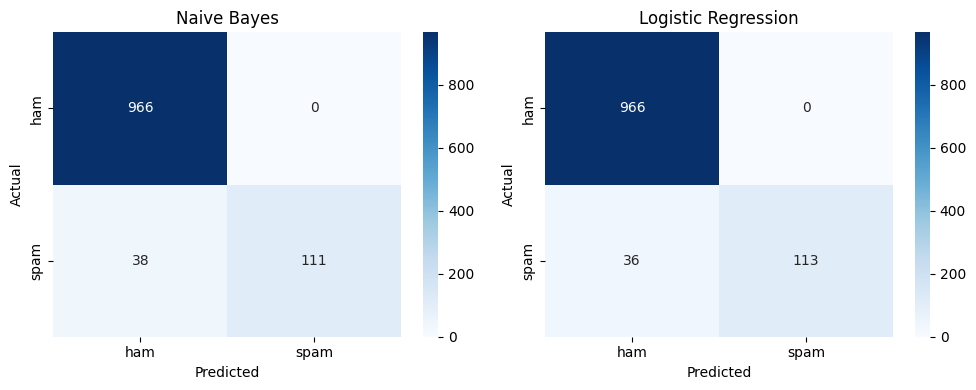


--- Test your own messages ---
HAM (spam probability: 27.3%)
HAM (spam probability: 1.4%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, [("Naive Bayes", nb), ("Logistic Regression", lr)]):
    y_pred = model.predict(X_test_tf)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=["ham","spam"]))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                xticklabels=["ham","spam"], yticklabels=["ham","spam"],
                cmap="Blues")
    ax.set_title(name)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

def predict_spam(message, model=lr):
    cleaned = preprocess(message)
    vec = tfidf.transform([cleaned])
    result = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][1]
    return f"{'SPAM' if result==1 else 'HAM'} (spam probability: {prob:.1%})"

print("\n--- Test your own messages ---")
print(predict_spam("Congratulations! You won a free iPhone. Click now!"))
print(predict_spam("Hey, are we still meeting for lunch tomorrow?"))
